# EDA корпуса правил настольных игр

## Цель
- Оценить качество исходных текстов после извлечения из PDF/OCR.
- Оценить качество очищенного корпуса, предназначенного для дальнейшей индексации в RAG.
- Проанализировать связь характеристик сырых текстов с результатами очистки.
- Понять, готовы ли очищенные данные к использованию в RAG-системе.
- Посмотреть на часто встречающиеся слова/биграммы/триграммы.

In [1]:
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Пути к данным


In [2]:
BASE_DIR = Path.cwd().parents[1]

METADATA_DIR = Path("metadata")
DOCS_CSV = METADATA_DIR / "docs.csv"
REPORT_CSV = METADATA_DIR / "rules_texts_cleaned_report.csv"

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "rules_texts"
CLEAN_GOOD_DIR = DATA_DIR / "rules_texts_cleaned_good"
CLEAN_QUAR_DIR = DATA_DIR / "rules_texts_cleaned_quarantine"

## Загрузка таблиц и базовые проверки


In [3]:
docs = pd.read_csv(DOCS_CSV)
rep = pd.read_csv(REPORT_CSV)

print("docs.csv:", len(docs))
print("rules_texts_cleaned_report.csv:", len(rep))

# Проверка ключей
print("Уникальных doc_sha256 в docs:", docs["doc_sha256"].nunique())
print("Уникальных raw_doc_sha256 в report:", rep["raw_doc_sha256"].nunique())

# Проверка пересечения
docs_set = set(docs["doc_sha256"].astype(str))
rep_set = set(rep["raw_doc_sha256"].astype(str))
print("Пересечение docs и report:", len(docs_set & rep_set))
print("В report, но нет в docs:", len(rep_set - docs_set))
print("В docs, но нет в report:", len(docs_set - rep_set))

print("\nФормат docs.csv")
display(docs.head(3))
print("Формат rules_texts_cleaned_report.csv")
display(rep.head(3))


docs.csv: 2711
rules_texts_cleaned_report.csv: 2711
Уникальных doc_sha256 в docs: 2711
Уникальных raw_doc_sha256 в report: 2711
Пересечение docs и report: 2711
В report, но нет в docs: 0
В docs, но нет в report: 0

Формат docs.csv


,doc_sha256,pdf_filename,pdf_url,text_path,primary_title,lang
0,659dadc07102ef7d251a37ce028ccc168139f86d2c12b2...,exploding-kittens-rules.pdf,https://www.mosigra.ru/download/rules/explodin...,data/rules_texts/659dadc07102ef7d251a37ce028cc...,Взрывные котята,ru
1,839a212c192c346dcf86e030257c9f3683d8f50f2a9ddf...,imadzhinarium.pdf,https://www.mosigra.ru/image/data/mosigra.prod...,data/rules_texts/839a212c192c346dcf86e030257c9...,Имаджинариум,ru
2,6a8756dbd14b967dd6782fd6a44b59500521ee2c6f77b2...,shakal-rules.pdf,https://www.mosigra.ru/download/rules/shakal-r...,data/rules_texts/6a8756dbd14b967dd6782fd6a44b5...,Шакал,ru


Формат rules_texts_cleaned_report.csv


,raw_doc_sha256,clean_sha256,clean_text_path,lang,pdf_filename,pdf_url,text_path,raw_len,clean_len,survival_ratio,paragraphs_total,paragraphs_bad,paragraphs_bad_ratio,quarantine
0,0003ea7cf163c9f46ccec250538d6534b61e0ae154dccf...,39178c116c263c19c2edb56dd97fdb294774a0e4a89ed2...,data/rules_texts_cleaned_good/0003ea7cf163c9f4...,ru,nepostizhimoe-koshmary-iz-puchiny-rules.pdf,https://www.mosigra.ru/download/rules/nepostiz...,data/rules_texts/0003ea7cf163c9f46ccec250538d6...,30661,28372,0.9253,72,3,0.0417,0
1,0016fae7e723b578f4a90da39ef7b89b44005b1b2aae94...,66d16dcfcb0d0843e3e0d58af9b3333a25c8e314de90fd...,data/rules_texts_cleaned_good/0016fae7e723b578...,ru,uzhas-arkhjema-tajnoe-poslanie-rules-01.pdf,https://www.mosigra.ru/download/rules/uzhas-ar...,data/rules_texts/0016fae7e723b578f4a90da39ef7b...,13901,13348,0.9602,31,0,0.0000,0
2,0069240e8f0166a5794ecddc5d632ea27b15474a2d6733...,81db5a4f59c2ec4c67491914d6a17993d7cb51e816644c...,data/rules_texts_cleaned_good/0069240e8f0166a5...,ru,streets_rules.pdf,https://www.mosigra.ru/download/Правила/street...,data/rules_texts/0069240e8f0166a5794ecddc5d632...,29255,28932,0.9890,24,0,0.0000,0


## Распределение по языкам


In [4]:
lang_counts = docs["lang"].fillna("unknown").value_counts()
print("Языки:", ", ".join(f"{k}: {v}" for k, v in lang_counts.items()))

Языки: ru: 2626, en: 85


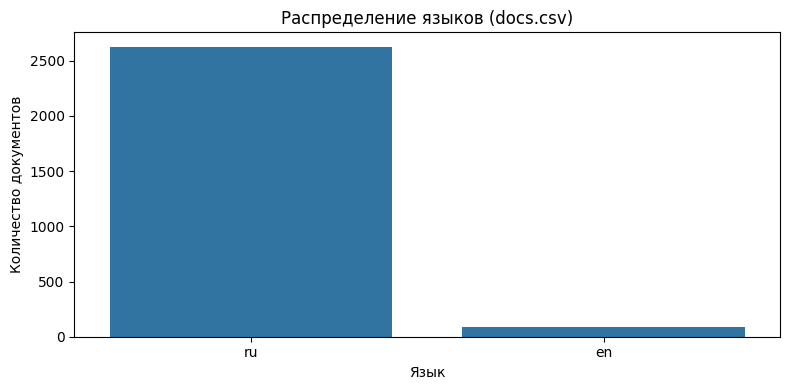

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=docs, x="lang", order=lang_counts.index)
plt.title("Распределение языков (docs.csv)")
plt.xlabel("Язык")
plt.ylabel("Количество документов")
plt.tight_layout()
plt.show()

# Часть 1. Анализ сырых текстов

## Метрики

- `alpha_ratio`: доля буквенных символов среди всех непробельных.
- `max_char_ratio`: доля наиболее частого символа среди непробельных.
- `one_letter_lines_ratio`: доля строк, состоящих из одной буквы.
- `entropy`: энтропия распределения символов.
- `n_lines`, `raw_chars`: размерности документа.


In [6]:
RE_ONE_LETTER_LINE = re.compile(r"^\s*[A-Za-zА-Яа-яЁё]\s*$")

def entropy_chars(text: str) -> float:
    s = "".join(ch for ch in text if not ch.isspace())
    if not s:
        return 0.0
    freq = Counter(s)
    n = len(s)
    ent = 0.0
    for c in freq.values():
        p = c / n
        ent -= p * np.log2(p)
    return float(ent)

def raw_metrics(text: str) -> dict:
    chars = [ch for ch in text if not ch.isspace()]
    if not chars:
        return {
            "raw_chars": 0,
            "alpha_ratio": 0.0,
            "max_char_ratio": 1.0,
            "one_letter_lines_ratio": 0.0,
            "entropy": 0.0,
            "n_lines": 0,
        }

    alpha_ratio = sum(ch.isalpha() for ch in chars) / len(chars)
    cnt = Counter(chars)
    max_char_ratio = max(cnt.values()) / len(chars)

    lines = text.splitlines()
    n_lines = len(lines)
    if n_lines:
        one_letter_lines = sum(1 for ln in lines if RE_ONE_LETTER_LINE.match((ln or "").strip()))
        one_letter_lines_ratio = one_letter_lines / n_lines
    else:
        one_letter_lines_ratio = 0.0

    ent = entropy_chars(text)

    return {
        "raw_chars": int(len(chars)),
        "alpha_ratio": float(alpha_ratio),
        "max_char_ratio": float(max_char_ratio),
        "one_letter_lines_ratio": float(one_letter_lines_ratio),
        "entropy": float(ent),
        "n_lines": int(n_lines),
    }


## Расчёт метрик по всем документам


In [7]:
def read_text_safe(path: Path) -> str:
    if not path.exists():
        return ""
    return path.read_text("utf-8", errors="ignore")

rows = []
for _, r in docs.iterrows():
    sha = str(r["doc_sha256"])
    rel_path = str(r.get("text_path", "")).strip()

    path = Path(rel_path) if rel_path else (RAW_DIR / f"{sha}.txt")
    if not path.exists():
        path = RAW_DIR / f"{sha}.txt"

    if not path.exists():
        continue

    raw = read_text_safe(path)
    m = raw_metrics(raw)
    rows.append({
        "doc_sha256": sha,
        "lang": (r.get("lang") or "unknown"),
        "primary_title": (r.get("primary_title") or ""),
        "pdf_url": (r.get("pdf_url") or ""),
        "text_path": (r.get("text_path") or ""),
        **m,
    })

raw_df = pd.DataFrame(rows)
print("Документов с рассчитанными raw-метриками:", len(raw_df))

Документов с рассчитанными raw-метриками: 2711


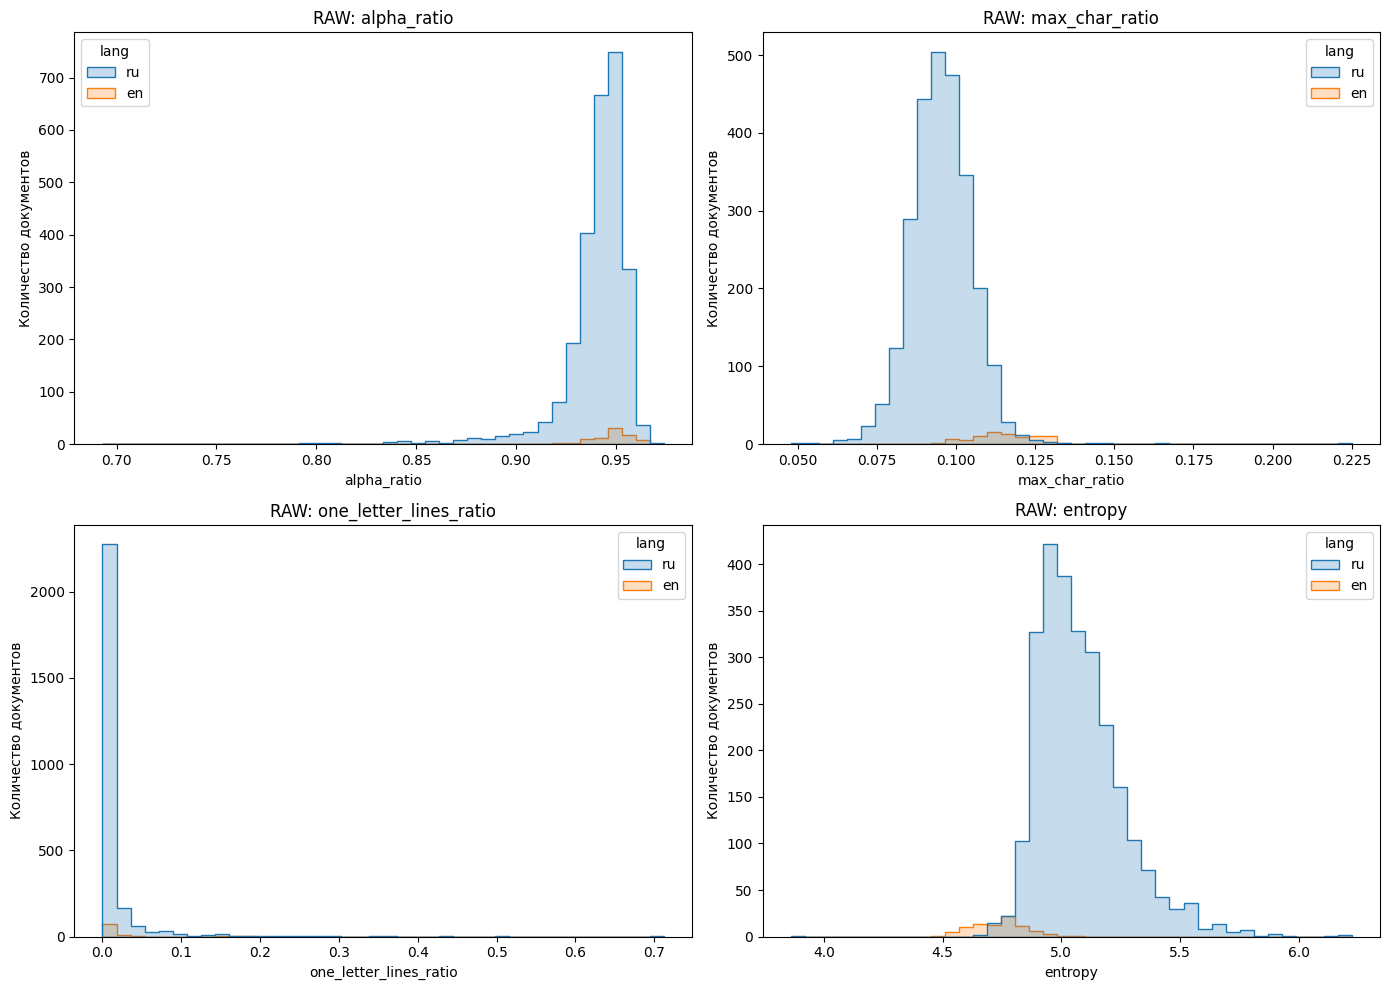

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=raw_df, x="alpha_ratio", bins=40, hue="lang", element="step", ax=ax[0, 0])
ax[0,0].set_title("RAW: alpha_ratio")
ax[0,0].set_xlabel("alpha_ratio")
ax[0,0].set_ylabel("Количество документов")

sns.histplot(data=raw_df, x="max_char_ratio", bins=40, hue="lang", element="step", ax=ax[0, 1])
ax[0,1].set_title("RAW: max_char_ratio")
ax[0,1].set_xlabel("max_char_ratio")
ax[0,1].set_ylabel("Количество документов")

sns.histplot(data=raw_df, x="one_letter_lines_ratio", bins=40, hue="lang", element="step", ax=ax[1, 0])
ax[1,0].set_title("RAW: one_letter_lines_ratio")
ax[1,0].set_xlabel("one_letter_lines_ratio")
ax[1,0].set_ylabel("Количество документов")

sns.histplot(data=raw_df, x="entropy", bins=40, hue="lang", element="step", ax=ax[1, 1])
ax[1,1].set_title("RAW: entropy")
ax[1,1].set_xlabel("entropy")
ax[1,1].set_ylabel("Количество документов")

plt.tight_layout()
plt.show()


Распределение `alpha_ratio` сконцентрировано на высоких значениях (пик около ~0.93–0.96), что означает преобладание буквенных символов в большинстве документов и в целом приемлемую читаемость raw-текста.

Для `max_char_ratio` основная масса документов находится в умеренной области, а правый хвост указывает на небольшую долю документов с высокой повторяемостью одного символа - типичный признак артефактов извлечения/разметки (например, "полосы" из одинаковых символов, разделители, дефекты OCR).

Метрика `one_letter_lines_ratio` у большинства документов близка к нулю, однако наличие редких выбросов говорит о документах, где структура строк нарушена (например, текст "рассыпался" на короткие строки/колонки или появились массовые разрывы строк после OCR).

Значения `entropy` для большинства документов лежат в узком диапазоне, а нетипично низкие значения выступают маркером "неестественного" распределения символов (низкое разнообразие, повторяемость), что также характерно для шумных/повреждённых raw-текстов.

## Наиболее проблемные сырые документы
Рейтинг строится по трём признакам: доля однобуквенных строк, повторяемость символов, доля буквенных символов.


In [9]:
raw_suspicious = (
    raw_df.sort_values(
        ["one_letter_lines_ratio", "max_char_ratio", "alpha_ratio"],
        ascending=[False, False, True]
    ).head(15)
)

display(raw_suspicious[[
    "doc_sha256", "lang", "primary_title","raw_chars", "n_lines",
    "alpha_ratio", "max_char_ratio", "one_letter_lines_ratio",
    "entropy", "pdf_url", "text_path"
]])


,doc_sha256,lang,primary_title,raw_chars,n_lines,alpha_ratio,max_char_ratio,one_letter_lines_ratio,entropy,pdf_url,text_path
2141,7c4ac8e0b0a41c9ea264e2ed5d502034de517d2c60650f...,ru,Улётные кошмарики,3915,952,0.928991,0.092465,0.712185,4.947508,https://www.mosigra.ru/download/rules/uletnye-...,data/rules_texts/7c4ac8e0b0a41c9ea264e2ed5d502...
2011,5db7a731cc60ef8f7adab1f6855adcaf8e8be30464de8c...,ru,Салат удачи,8622,1230,0.926931,0.098585,0.504065,5.404614,https://www.mosigra.ru/download/Правила/PS_Rul...,data/rules_texts/5db7a731cc60ef8f7adab1f6855ad...
933,4d1a4a1a7ecf54e9e1ca93a2ce5e84e83c8ed3a61cbac2...,ru,Слово за Слово. Замес,5893,496,0.928729,0.093840,0.443548,5.284774,https://www.mosigra.ru/download/rules/slovo-za...,data/rules_texts/4d1a4a1a7ecf54e9e1ca93a2ce5e8...
2304,fb0e199fa1fb39c095978075000d916247e805720f9b01...,ru,Крути педали!,10613,745,0.942994,0.076321,0.367785,5.603505,https://www.mosigra.ru/image/data/mosigra.prod...,data/rules_texts/fb0e199fa1fb39c095978075000d9...
1208,3a189c9e555e532437b23c8b7bee1825ec5f692f27838b...,ru,Квич,4687,539,0.896309,0.084276,0.341373,5.140804,https://www.mosigra.ru/download/rules/kvich.pdf,data/rules_texts/3a189c9e555e532437b23c8b7bee1...
1794,ca2f2580b910cd577ab84d8b0ec991cd0398039cc85cbe...,ru,Ансамбль,5680,312,0.952465,0.113908,0.339744,4.904213,https://www.mosigra.ru/download/Правила/EN_rul...,data/rules_texts/ca2f2580b910cd577ab84d8b0ec99...
91,fcd2c49ee8154ce2e41282aa7a068e6fbda2054efe46e3...,ru,Ticket to Ride. Наследие: Легенды Запада,27306,1430,0.952391,0.091372,0.288112,5.146660,https://www.mosigra.ru/download/Правила/TTR_Wi...,data/rules_texts/fcd2c49ee8154ce2e41282aa7a068...
545,dcc4c1a3d54a854fe0607e741db29eb0ca19fc73fc8bff...,ru,ЗлоуМЫШленники [Предзаказ],9590,653,0.936809,0.098540,0.281776,5.058330,https://www.mosigra.ru/download/rules/zloumish...,data/rules_texts/dcc4c1a3d54a854fe0607e741db29...
777,4b9181d6fec6ceecc2c42db05cbb6fddda6d2c1e7b865d...,ru,Слово волка,12839,1043,0.922580,0.097437,0.269415,5.446872,https://www.mosigra.ru/download/rules/slovo-vo...,data/rules_texts/4b9181d6fec6ceecc2c42db05cbb6...
1068,64d9b3d2e31df83f6bf2e5f18a86a9220412b4828c5b76...,ru,Тропы Туканы,12836,733,0.940402,0.101589,0.259209,5.118972,https://www.mosigra.ru/download/Правила/Rules_...,data/rules_texts/64d9b3d2e31df83f6bf2e5f18a86a...


# Часть 2. Анализ результатов очистки

## Очистка текстов

Очистка корпуса выполнена скриптом `rules_cleaner.py` и включает последовательность этапов нормализации, удаления строковых артефактов и фильтрации абзацев по эвристическим показателям качества. 
На первом этапе текст приводится к единому формату: унифицируются переводы строк, применяется Unicode-нормализация (NFKC), удаляются некоторые невидимые символы (например, soft hyphen, zero-width space, BOM), непечатаемые управляющие символы и пробелы в конце строк.

Далее выполняется построчная очистка: удаляются строки с номерами страниц (шаблоны вида «стр. 3», «page 2», «—N—»), «мусорные» строки (разделители из символов, короткие строки только из чисел), строки из одной пунктуации (например «.», «••»). В начале и конце документа дополнительно пропускаются строки вида «Правила игры скачаны с …» и маркетинговые фразы (производитель игр, сеть магазинов). Удаляются последовательности строк из одной буквы или строк, состоящих преимущественно из неалфавитных символов; множественные пробелы схлопываются.
Для снижения влияния колонтитулов используется механизм `global boilerplate`: по каждому языку собираются повторяющиеся строки в первых и последних строках документов, и такие строки удаляются при очистке (параметры `boilerplate_scan_lines`, `boilerplate_min_docs`). При переносах слов на дефисе выполняется де-дефисизация: если строка заканчивается дефисом, а следующая начинается со слова, перенос склеивается в одно слово. Внутри строк схлопывается повторяющаяся фраза (например «A A» → «A»), удаляются подряд идущие одинаковые строки.

После построчной очистки выполняется объединение строк внутри абзацев: строки внутри абзаца склеиваются, а границы сохраняются для списков, заголовков и коротких строк, которые по эвристикам считаются структурными элементами документа.
Перед сегментацией на абзацы выполняется вставка двойного переноса перед строками-заголовками разделов (ФАЗА N, Подготовка к игре, Компоненты, Игровой процесс и т.п.), чтобы при последующем чанкинге заголовок оказывался в начале своего абзаца/чанка, а не в конце предыдущего. Заголовком считается только строка, совпадающая с явными паттернами (фазы/шаги, типичные разделы правил RU/EN, «раздел/глава/приложение»); общая эвристика «короткая строка в верхнем регистре или с двоеточием» не используется, чтобы не создавать лишние абзацы перед подписями к схемам (например «5 ШИРМ», «ДЛЯ ПОДСЧЁТА»), которые иначе становились бы отдельными короткими абзацами и отбрасывались, увеличивая карантин.
Далее текст сегментируется на абзацы как блоки, разделённые пустыми строками, после чего каждый абзац оценивается по показателям `alpha_ratio`, `max_char_ratio` и энтропии; абзацы, не проходящие пороги, удаляются из финального cleaned-текста. Абзацы, совпадающие с заголовком раздела, сохраняются даже если короткие (не считаются «плохими»).

Документ помечается флагом `quarantine`, если очищенный текст пустой, либо коэффициент сохранения `survival_ratio` ниже порога (`min_survival_ratio=0.5`), либо доля удалённых абзацев `paragraphs_bad_ratio` превышает порог (`max_bad_paragraph_ratio = 0.4`).

## Метрики

- `raw_len`: длина исходного текста после нормализации (число символов).
- `clean_len`: длина очищенного текста (число символов).
- `survival_ratio`: коэффициент сохранения текста, доля (clean_len / raw_len).
- `paragraphs_total`: число абзацев в нормализованном тексте перед фильтрацией по качеству (абзац определяется как блок текста между пустыми строками).
- `paragraphs_bad`: число абзацев, отфильтрованных как низкокачественные по эвристикам (например, низкая доля букв, высокая повторяемость символов и т.п.). Абзацы, совпадающие с заголовком раздела (ФАЗА N, Подготовка к игре, Компоненты и т.п.), сохраняются и не входят в `paragraphs_bad` (в отчёте по причинам — `header_kept`).
- `paragraphs_bad_ratio`: доля отфильтрованных абзацев, (paragraphs_bad / paragraphs_total).

## Доля карантина

In [10]:
print(f"Доля документов в карантине: {rep['quarantine'].mean():.3f} ({(rep['quarantine']==1).sum()}/{len(rep)})")

Доля документов в карантине: 0.009 (24/2711)


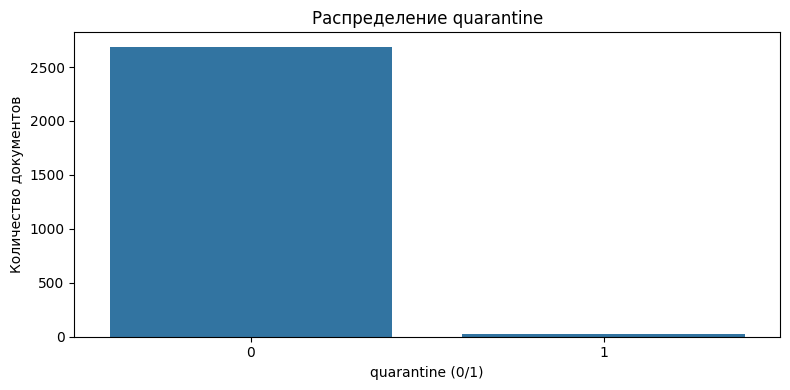

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(data=rep, x="quarantine")
plt.title("Распределение quarantine")
plt.xlabel("quarantine (0/1)")
plt.ylabel("Количество документов")
plt.tight_layout()
plt.show()

По результатам очистки доля документов, отправленных в карантин, составляет <1% (24 из 2711), то есть подавляющее большинство документов проходит quality gate.

In [12]:
rep2 = rep.merge(
    docs[["doc_sha256", "primary_title"]],
    left_on="raw_doc_sha256",
    right_on="doc_sha256",
    how="left"
).drop(columns=["doc_sha256"])


## Распределение `survival_ratio` и `paragraphs_bad_ratio`

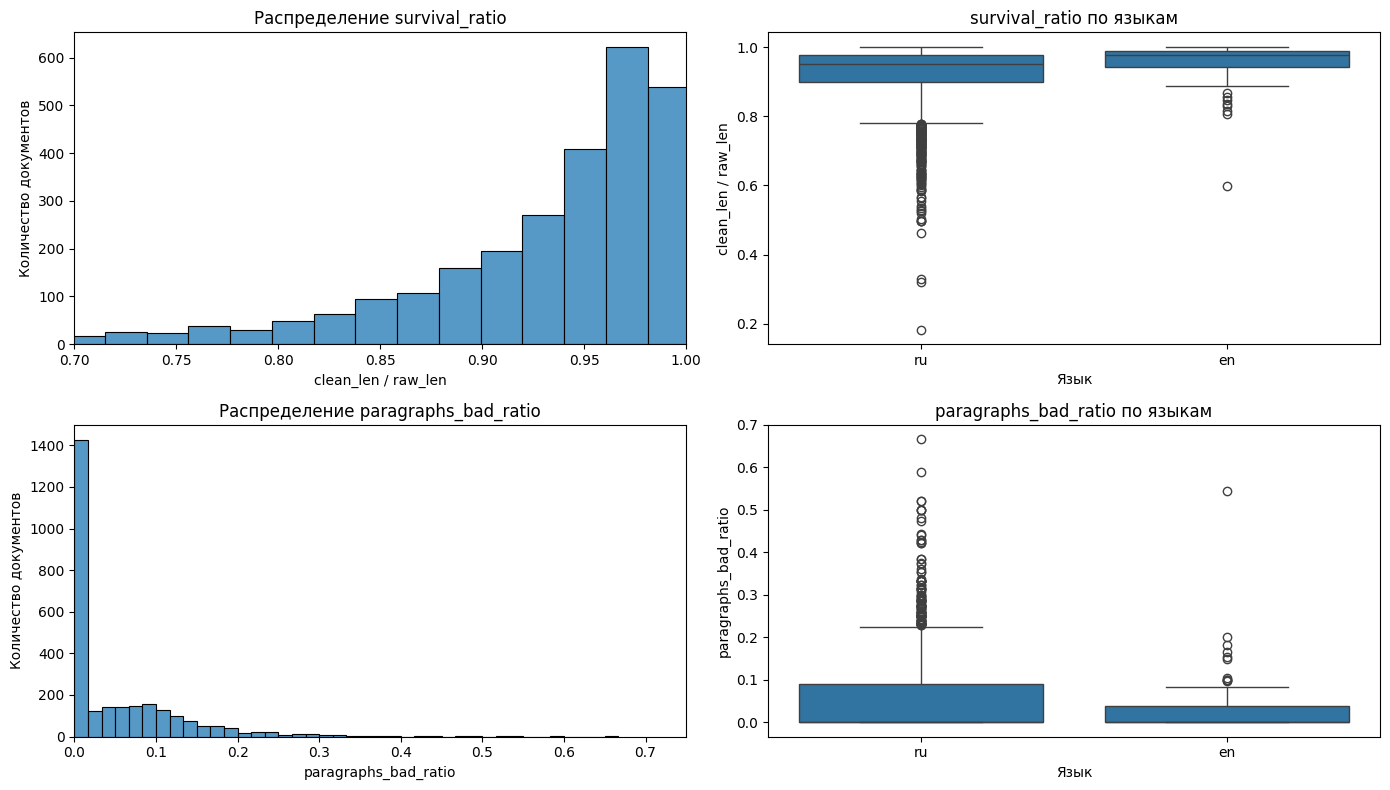

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(data=rep2, x="survival_ratio", bins=40, ax=ax[0, 0])
ax[0][0].set_title("Распределение survival_ratio")
ax[0][0].set_xlabel("clean_len / raw_len")
ax[0][0].set_ylabel("Количество документов")
ax[0, 0].set_xlim(0.7, 1.0)

sns.boxplot(data=rep2, x="lang", y="survival_ratio", ax=ax[0, 1])
ax[0][1].set_title("survival_ratio по языкам")
ax[0][1].set_xlabel("Язык")
ax[0][1].set_ylabel("clean_len / raw_len")

sns.histplot(data=rep2, x="paragraphs_bad_ratio", bins=40, ax=ax[1, 0])
ax[1][0].set_title("Распределение paragraphs_bad_ratio")
ax[1][0].set_xlabel("paragraphs_bad_ratio")
ax[1][0].set_ylabel("Количество документов")
ax[1, 0].set_xlim(0.0, 0.75)

sns.boxplot(data=rep2, x="lang", y="paragraphs_bad_ratio", ax=ax[1, 1])
ax[1][1].set_title("paragraphs_bad_ratio по языкам")
ax[1][1].set_xlabel("Язык")
ax[1][1].set_ylabel("paragraphs_bad_ratio")

plt.tight_layout()
plt.show()


Распределение `survival_ratio` смещено к высоким значениям (основная масса документов близка к `0.9–1.0`), что означает: после очистки обычно сохраняется почти весь нормализованный текст, а удаляется преимущественно шум; при этом по boxplot заметно, что у `ru` разброс больше и встречаются редкие низкие выбросы, тогда как `en` выглядит более стабильным.

Распределение `paragraphs_bad_ratio` имеет сильную концентрацию у нуля, то есть для большинства документов абзацная фильтрация почти ничего не выбрасывает, но хвост с редкими высокими значениями (особенно в `ru`) показывает наличие небольшой доли проблемных извлечений/OCR, где значимая часть абзацев распознаётся как некачественная и удаляется.

## Документы с наихудшим сохранением текста


In [14]:
worst = rep2.sort_values("survival_ratio").head(15)[[
    "raw_doc_sha256", "clean_sha256", "lang", "primary_title",
    "raw_len", "clean_len", "survival_ratio",
    "paragraphs_bad_ratio", "quarantine",
    "pdf_url", "text_path", "clean_text_path"
]]
display(worst)


,raw_doc_sha256,clean_sha256,lang,primary_title,raw_len,clean_len,survival_ratio,paragraphs_bad_ratio,quarantine,pdf_url,text_path,clean_text_path
134,0c34c5ea234d82a3dcc3ddc6e19d53d4bacda53939f0eb...,a57451cd4fb3303d63bdab9fc6eac0f0bda65c7102b7d0...,ru,Детективные истории: Последний рейс Гаттардо,2812,514,0.1828,0.0000,1,https://www.mosigra.ru/download/Правила/gattar...,data/rules_texts/0c34c5ea234d82a3dcc3ddc6e19d5...,data/rules_texts_cleaned_quarantine/0c34c5ea23...
1953,ba7220a09c5ada4246db4949ac73ff41137185d0e27996...,b4d986e21c1ee3ccca7098d2fd6a47936c4288e85bf03b...,ru,Манчкин. WARHAMMER 40 000: Огнём и верой,3843,1231,0.3203,0.0000,1,https://www.mosigra.ru/download/Правила/Munchk...,data/rules_texts/ba7220a09c5ada4246db4949ac73f...,data/rules_texts_cleaned_quarantine/ba7220a09c...
1987,bdc990071d890fe0a2de04e350ef338876695f8f90037b...,ff03c1d55d6487ed1da3dc189d7e48936237e105f780f8...,ru,Сплэш!,3219,1061,0.3296,0.0000,1,https://www.mosigra.ru/download/Правила/Правил...,data/rules_texts/bdc990071d890fe0a2de04e350ef3...,data/rules_texts_cleaned_quarantine/bdc990071d...
47,056fbbb5f6131577cc0aec8ca65fb3ef50a2c6c77f65fb...,4d78e1cd121b4eae6b28cdb390327a9cf453a2ec44e10a...,ru,Манчкин 10: Искривляние времени,2786,1291,0.4634,0.0000,1,https://www.mosigra.ru/download/Правила/Munchk...,data/rules_texts/056fbbb5f6131577cc0aec8ca65fb...,data/rules_texts_cleaned_quarantine/056fbbb5f6...
2014,bf9be2b18dd3e0d2ab6992b954b02d9c4c3a09a5fd16a4...,62094fc75a9c51c1b608df14e204d90996bc1a8bb9a235...,ru,Русский Манчкин 2: Комическая гонка,3095,1541,0.4979,0.0000,1,https://www.mosigra.ru/download/rules/rules-ru...,data/rules_texts/bf9be2b18dd3e0d2ab6992b954b02...,data/rules_texts_cleaned_quarantine/bf9be2b18d...
2297,db972c4d8803fcb44e27375267559f671694cec98c543c...,66a7e17dc9d240e0e0f43e22852cae31680ce249103299...,ru,"Ну, погоди: Команда мечты",7817,3895,0.4983,0.0000,1,https://www.mosigra.ru/download/rules/nu-pogod...,data/rules_texts/db972c4d8803fcb44e27375267559...,data/rules_texts_cleaned_quarantine/db972c4d88...
2522,f00a87eaadabf9d24eae976f42396571b6f1b0dab44177...,7e3bba5c4c9a525f1c09a5bfe139a46f8e15e86bb9b14c...,ru,Зомбицид: Iron Maiden. Набор №3,5088,2537,0.4986,0.0000,1,https://www.mosigra.ru/download/rules/zombicid...,data/rules_texts/f00a87eaadabf9d24eae976f42396...,data/rules_texts_cleaned_quarantine/f00a87eaad...
1822,adaa2ef0357df37ff5dfa8dcfd48e0921928ac4d7f1178...,3a9a111913154e604006df7ee746b079939a2ceb77b62b...,ru,Чёртова дилемма,4897,2467,0.5038,0.0000,0,https://www.mosigra.ru/download/rules/chertova...,data/rules_texts/adaa2ef0357df37ff5dfa8dcfd48e...,data/rules_texts_cleaned_good/adaa2ef0357df37f...
1755,a816e4b04d13c96977755c3b464c3c63d1009a21a5397e...,69b6d82cc5bec2d6dfe363a8d234aa6104a439b2dee72c...,ru,Войны Чёрной Розы: Скрытые шипы,12445,6493,0.5217,0.0000,0,https://www.mosigra.ru/download/Правила/BRW_Hi...,data/rules_texts/a816e4b04d13c96977755c3b464c3...,data/rules_texts_cleaned_good/a816e4b04d13c969...
475,2fb1bc4ad999bc4dda722613af28d9b9de3c9144dbe9e3...,3d43e0053f75d0b69c3af8252882de06ed56d15b5b31a5...,ru,Игра престолов. Танец с драконами,4978,2624,0.5271,0.1818,0,https://www.mosigra.ru/image/data/mosigra.prod...,data/rules_texts/2fb1bc4ad999bc4dda722613af28d...,data/rules_texts_cleaned_good/2fb1bc4ad999bc4d...


В топ‑15 документов с минимальным `survival_ratio` значения опускаются примерно до `~0.18–0.50`, то есть для небольшой доли корпуса очистка оставляет заметно меньше половины исходного текста.

При выбранных порогах quality‑gate (`min_survival_ratio=0.5`, `max_bad_paragraph_ratio=0.4`) в карантин попадают прежде всего документы с `survival_ratio < 0.5`, при этом в показанных примерах `paragraphs_bad_ratio` остаётся околонулевым.

Таким образом, quarantine‑фильтр работает как защита RAG‑индекса: он отсекает крайние случаи, где после очистки/фильтрации остаётся слишком мало текста для надёжной индексации, даже если формально текст выглядит "чистым" по `paragraphs_bad_ratio`.


## Связь raw-метрик и результатов очистки

In [15]:
cmp = raw_df.merge(
    rep2[["raw_doc_sha256", "survival_ratio", "paragraphs_bad_ratio", "quarantine"]],
    left_on="doc_sha256",
    right_on="raw_doc_sha256",
    how="left"
).drop(columns=["raw_doc_sha256"])


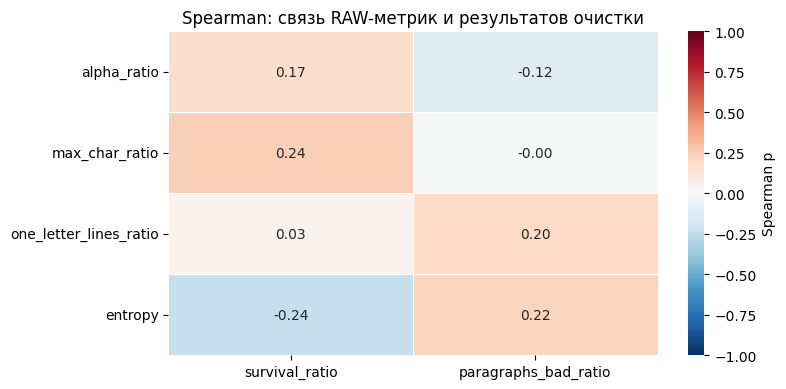

In [16]:
raw_cols = ["alpha_ratio", "max_char_ratio", "one_letter_lines_ratio", "entropy"]
clean_cols = ["survival_ratio", "paragraphs_bad_ratio"]

corr = cmp[raw_cols + clean_cols].corr(method="spearman")
block = corr.loc[raw_cols, clean_cols]

plt.figure(figsize=(8, 4))
sns.heatmap(
    block,
    cmap="RdBu_r",
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Spearman p"}
)
plt.title("Spearman: связь RAW-метрик и результатов очистки")
plt.tight_layout()
plt.show()


Наиболее заметная связь с результатом очистки наблюдается у `entropy`: она умеренно отрицательно коррелирует с `survival_ratio` и слабо положительно - с `paragraphs_bad_ratio`, то есть более "хаотичный" raw‑текст в среднем сохраняется хуже и чаще даёт больший процент отбракованных абзацев.

`alpha_ratio` показывает слабоположительную связь с `survival_ratio` и слабонегативную с `paragraphs_bad_ratio`: чем больше букв в сыром тексте, тем немного больше контента обычно переживает очистку, и тем чуть реже абзацы проваливают quality‑фильтр.

Для `max_char_ratio` связь с `paragraphs_bad_ratio` практически отсутствует, а с `survival_ratio` слабоположительная. Это может означать, что повышенная повторяемость символов встречается не только в "мусорных" фрагментах, но и в нормальных структурах текста (например, форматирование/разделители), поэтому по этой метрике трудно надёжно предсказывать долю удалённых абзацев.

`one_letter_lines_ratio` почти не связан с `survival_ratio`, но имеет слабоположительную связь с `paragraphs_bad_ratio`, что похоже на индикатор OCR/разметочных артефактов, повышающих вероятность отбраковки абзацев, но не обязательно уменьшающих общий объём выжившего текста.

**Корреляции отражают монотонные ассоциации и не доказывают причинно‑следственную связь; часть потерь может объясняться специфическими артефактами PDF/OCR, которые не полностью описываются raw‑метриками.**

## Анализ cleaned-текстов (GOOD)
Анализ выполняется для документов, не отправленных в карантин.

In [17]:
rep_good = rep2[rep2["quarantine"] == 0].copy()
print("GOOD документов:", len(rep_good))

def load_clean_text(row) -> str:
    path = str(row.get("clean_text_path") or "").strip()
    if not path:
        return ""
    return read_text_safe(BASE_DIR / path)

text_df = rep_good[[
    "raw_doc_sha256",
    "clean_sha256",
    "lang",
    "primary_title",
    "pdf_url",
    "clean_text_path"
]].copy()
text_df["text"] = text_df.apply(load_clean_text, axis=1)
text_df["text_len_chars"] = text_df["text"].str.len()

print("Пустых текстов в GOOD:", int((text_df["text_len_chars"] == 0).sum()))

GOOD документов: 2687
Пустых текстов в GOOD: 0


### Распределение длины cleaned-документов

In [18]:
TOKEN_RE = re.compile(
    r"(?:"
    r"[A-Za-zА-Яа-яЁё]+(?:-[A-Za-zА-Яа-яЁё]+)*" # слова, включая дефисные
    r"|\d+(?:\.\d+){1,6}" # секции: 1.2.3
    r"|\d+(?:[.,]\d+)?(?:[–-]\d+(?:[.,]\d+)?)?" # числа и диапазоны: 2, 2.5, 2–4, 1-3
    r")",
    re.UNICODE,
)
SENT_RE = re.compile(r"(?<!\d)[.!?]+(?!\d)(?=(?:\s|$))")


def get_tokens(text: str) -> list[str]:
    return [t.lower() for t in TOKEN_RE.findall(text)]


text_df["tokens"] = text_df["text"].map(get_tokens)
text_df["n_tokens"] = text_df["tokens"].map(len)
text_df["n_sents"] = text_df["text"].map(lambda s: len([x for x in SENT_RE.split(s) if x.strip()]))

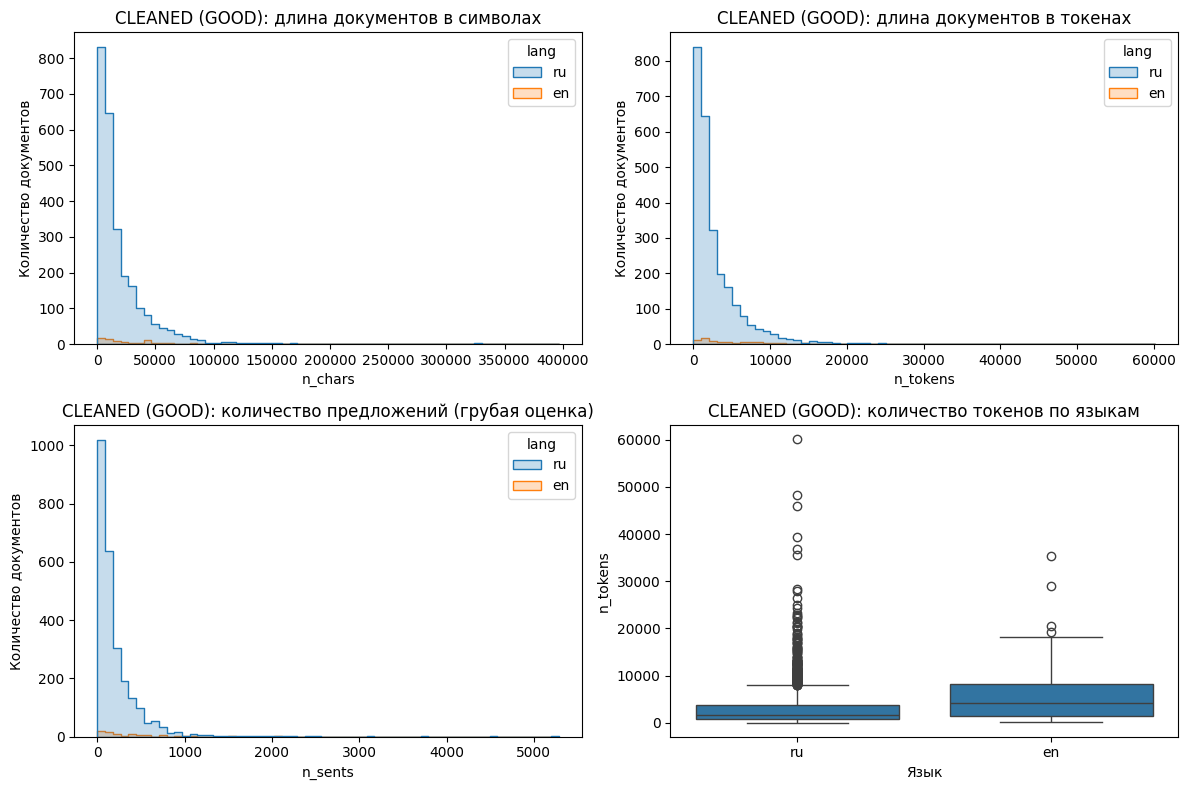

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=text_df, x="text_len_chars", hue="lang", bins=60, element="step", ax=ax[0, 0])
ax[0][0].set_title("CLEANED (GOOD): длина документов в символах")
ax[0][0].set_xlabel("n_chars")
ax[0][0].set_ylabel("Количество документов")

sns.histplot(data=text_df, x="n_tokens", hue="lang", bins=60, element="step", ax=ax[0, 1])
ax[0][1].set_title("CLEANED (GOOD): длина документов в токенах")
ax[0][1].set_xlabel("n_tokens")
ax[0][1].set_ylabel("Количество документов")

sns.histplot(data=text_df, x="n_sents", hue="lang", bins=60, element="step", ax=ax[1, 0])
ax[1][0].set_title("CLEANED (GOOD): количество предложений (грубая оценка)")
ax[1][0].set_xlabel("n_sents")
ax[1][0].set_ylabel("Количество документов")

sns.boxplot(data=text_df, x="lang", y="n_tokens", ax=ax[1, 1])
ax[1][1].set_title("CLEANED (GOOD): количество токенов по языкам")
ax[1][1].set_xlabel("Язык")
ax[1][1].set_ylabel("n_tokens")

plt.tight_layout()
plt.show()


Длины очищенных документов в символах и word‑like токенах распределены с выраженным длинным хвостом: основная масса документов короткая/средняя, но присутствуют редкие очень большие правила.

Оценка числа предложений также имеет длинный хвост, но её корректнее интерпретировать как число сегментов/границ предложений по эвристике, потому что форматирование (списки, оглавления) может завышать счётчик даже при более "умных" сегментаторах.

По boxplot видно, что количество токенов у en в среднем выше, чем у ru, однако выборка en существенно меньше.

### Лексические характеристики

Рассчитываются размер словаря и type-token ratio (TTR) по языкам.

In [20]:
def vocab_stats(sub: pd.DataFrame) -> dict:
    all_tokens = [t for toks in sub["tokens"] for t in toks]
    if not all_tokens:
        return {"n_docs": int(len(sub)), "n_tokens": 0, "vocab_size": 0, "ttr": 0.0}
    vocab = set(all_tokens)
    return {
        "n_docs": int(len(sub)),
        "n_tokens": int(len(all_tokens)),
        "vocab_size": int(len(vocab)),
        "ttr": float(len(vocab) / len(all_tokens)),
    }

stats = []
for lang, sub in text_df.groupby("lang"):
    s = vocab_stats(sub)
    s["lang"] = lang
    stats.append(s)

vocab_df = pd.DataFrame(stats)[[
    "lang",
    "n_docs",
    "n_tokens",
    "vocab_size",
    "ttr"
]].sort_values("n_docs", ascending=False)
display(vocab_df)


,lang,n_docs,n_tokens,vocab_size,ttr
1,ru,2603,7828022,210355,0.026872
0,en,84,522772,17318,0.033127


Размер словаря на русском языке значительно выше по сравнению с английским, что ожидаемо из‑за большего объёма текста и морфологического разнообразия русского языка.

TTR (type-token ratio) низкий в обеих группах, что указывает на сильную повторяемость лексики в правилах (типовые формулировки, повтор терминов, структуры "ход/фаза/игрок/карта" и т.д.).

### Частотность N-грамм

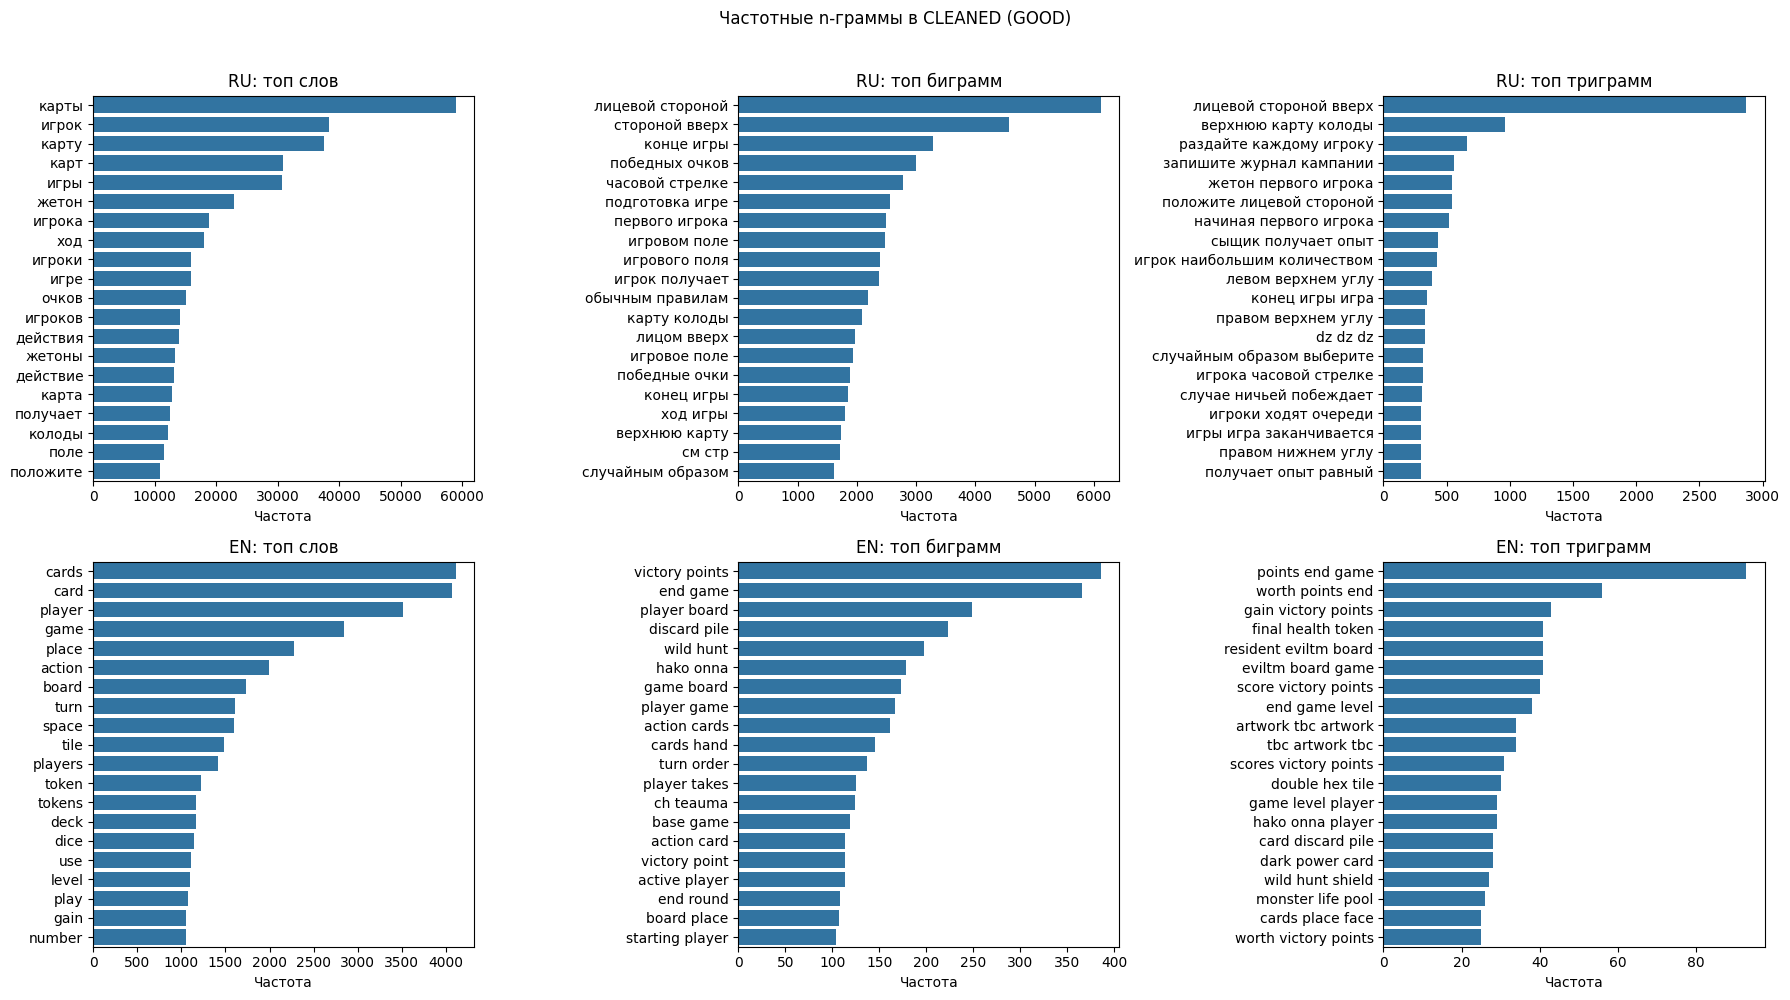

In [21]:
from spacy.lang.ru.stop_words import STOP_WORDS as RU_STOP
from spacy.lang.en.stop_words import STOP_WORDS as EN_STOP

def get_stop(lang: str) -> set:
    if lang == "ru":
        return RU_STOP
    if lang == "en":
        return EN_STOP
    return set()

def filter_tokens(tokens, stop, min_len=2, keep_alpha=True):
    out = []
    for token in tokens:
        if not token:
            continue
        token = token.lower()
        if len(token) < min_len:
            continue
        if token in stop:
            continue
        if keep_alpha and not token.isalpha():
            continue
        out.append(token)
    return out

def top_ngrams(
    text_df: pd.DataFrame,
    lang: str,
    n: int,
    topk=25,
    min_len=2,
    keep_alpha=True
) -> pd.DataFrame:
    cnt = Counter()
    sub = text_df[text_df["lang"] == lang]

    stop = get_stop(lang)
    for tokens in sub["tokens"]:
        tokens = filter_tokens(tokens, stop, min_len=min_len, keep_alpha=keep_alpha)
        if len(tokens) < n:
            continue
        for ngram in zip(*[tokens[i:] for i in range(n)]):
            cnt[ngram] += 1

    rows = []
    for ngram, cnt in cnt.most_common(topk):
        label = " ".join(ngram)
        rows.append((label, cnt))

    return pd.DataFrame(rows, columns=["ngram", "count"])

def plot_top_ngrams(df: pd.DataFrame, ax, title: str):
    ax.set_title(title)

    if df.empty:
        ax.text(0.5, 0.5, "Нет данных", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    
    df = df.sort_values("count", ascending=False)
    
    sns.barplot(data=df, x="count", y="ngram", ax=ax)
    ax.set_xlabel("Частота")
    ax.set_ylabel("")

def plot_language_ngrams(text_df: pd.DataFrame, topk=25):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False)
    
    langs = ["ru", "en"]
    ns = [1, 2, 3]
    col_titles = {1: "топ слов", 2: "топ биграмм", 3: "топ триграмм"}
    for i, lang in enumerate(langs):
        for j, n in enumerate(ns):
            df = top_ngrams(text_df=text_df, lang=lang, n=n, topk=topk)
            plot_top_ngrams(df, axes[i, j], f"{lang.upper()}: {col_titles[n]}")

    fig.suptitle("Частотные n-граммы в CLEANED (GOOD)", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

plot_language_ngrams(text_df, topk=20)


Частотные n‑граммы в CLEANED (GOOD) в целом выглядят как содержательные элементы правил (RU: "карты/игрок/жетон", устойчивые инструкции вроде "положите лицевой стороной вверх"; EN: "victory points", "end game", "discard pile"), что указывает на то, что очистка в основном оставляет именно операционный текст правил и не "засоряет" корпус служебными вставками, хотя в английской части заметны отдельные артефакты издательского/технического хвоста (например, catan gmbh …, spellbook … indd), которые локально не влияют на доминирующий профиль корпуса.


## Вывод по результатам очистки

Очищенный корпус (GOOD) пригоден для дальнейшей подготовки к индексации: тексты нормализованы, метрики очистки показывают стабильное качество, а распределения длины имеют ожидаемый длинный хвост, который требует разбиения документов на чанки перед загрузкой в векторную БД.